<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [8]:
!pip install pandas
!pip install matplotlib


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

#### Step 1: Load the dataset


In [13]:
df.columns.tolist()
print(df.dtypes)

ResponseId               int64
MainBranch                 str
Age                        str
Employment                 str
RemoteWork                 str
                        ...   
JobSatPoints_11        float64
SurveyLength               str
SurveyEase                 str
ConvertedCompYearly    float64
JobSat                 float64
Length: 114, dtype: object


In [11]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 


### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




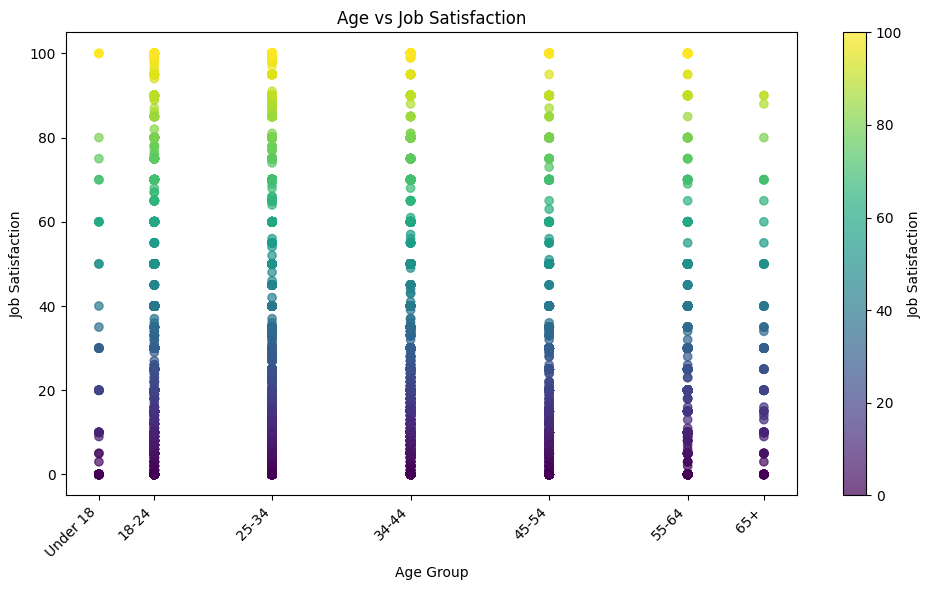

In [23]:
## Write your code here
age_map = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5 ,    
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 65}

df['Age_num'] = df['Age'].map(age_map)

plot_df = df[['Age_num', 'JobSatPoints_6']].copy()
plot_df = plot_df.dropna()

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    plot_df['Age_num'],
    plot_df['JobSatPoints_6'],
    c=plot_df['JobSatPoints_6'],
    cmap='viridis',
    alpha=0.7)

plt.colorbar(scatter, label='Job Satisfaction')
        
plt.title('Age vs Job Satisfaction')
plt.xlabel('Age Group')
plt.ylabel('Job Satisfaction')
plt.xticks(
    [17, 21, 29.5, 39.5, 49.5, 59.5, 65],
    ['Under 18', '18-24', '25-34', '34-44', '45-54', '55-64', '65+'],
    rotation=45, ha='right')
plt.tight_layout()
plt.show()


#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


In [31]:
df['ConvertedCompYearly'].value_counts()

ConvertedCompYearly
64444.0     321
53703.0     308
75184.0     230
85925.0     226
107406.0    208
           ... 
152615.0      1
4364.0        1
15637.0       1
9711.0        1
116844.0      1
Name: count, Length: 6113, dtype: int64

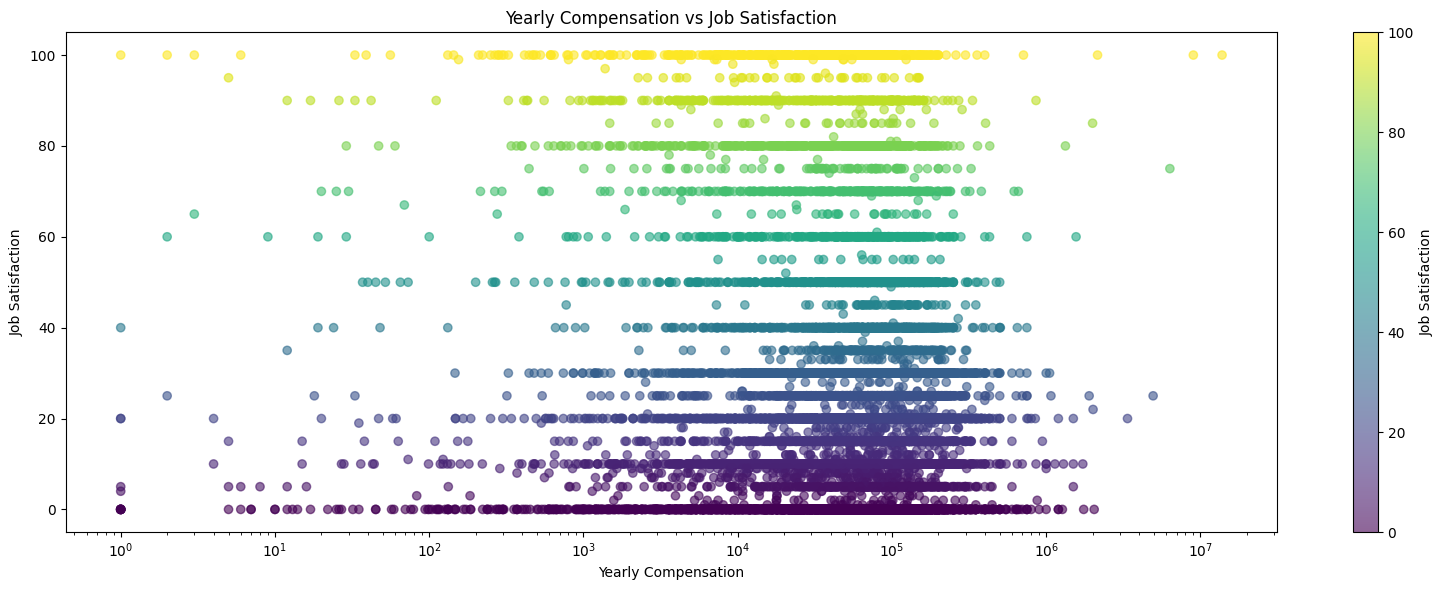

In [39]:
## Write your code here
#ConvertedCompYearly, JobSatPoints_6
comp.describe()

Comp_df= df[['ConvertedCompYearly', 'JobSatPoints_6']].copy()
Comp_df = Comp_df.dropna()

plt.figure(figsize=(16, 6))
scatter = plt.scatter(
    Comp_df['ConvertedCompYearly'],
    Comp_df['JobSatPoints_6'],
    c=Comp_df['JobSatPoints_6'],
    cmap='viridis',
    alpha=0.6)

plt.colorbar(scatter, label='Job Satisfaction')
        
plt.title('Yearly Compensation vs Job Satisfaction')
plt.xlabel('Yearly Compensation')
plt.ylabel('Job Satisfaction')
plt.xscale('log')
plt.tight_layout()
plt.show()

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


In [41]:
!pip install numpy
import numpy as np

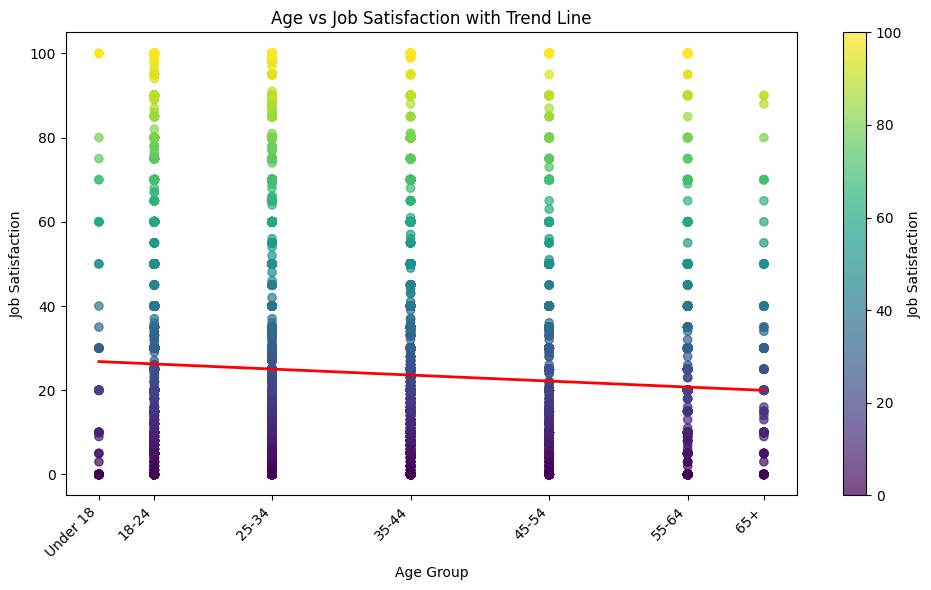

In [45]:
age_map = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5 ,    
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 65}

df['Age_num'] = df['Age'].map(age_map)

plot_df = df[['Age_num', 'JobSatPoints_6']].copy()
plot_df = plot_df.dropna()

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    plot_df['Age_num'],
    plot_df['JobSatPoints_6'],
    c=plot_df['JobSatPoints_6'],
    cmap='viridis',
    alpha=0.7)

plt.colorbar(scatter, label='Job Satisfaction')

#creating a Regression Line, sorting the x values before plotting
x =  plot_df['Age_num']
y =  plot_df['JobSatPoints_6']

m, b = np.polyfit(x, y, 1)

sorted_idx = x.argsort()
x_sorted = x.iloc[sorted_idx]
y_pred = m * x_sorted + b

#m=slope, b=intercept
plt.plot(x_sorted, y_pred, color='red', linewidth=2)

plt.title('Age vs Job Satisfaction with Trend Line')
plt.xlabel('Age Group')
plt.ylabel('Job Satisfaction')
plt.xticks(
    [17, 21, 29.5, 39.5, 49.5, 59.5, 65],
    ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+'],
    rotation=45, ha='right')
plt.tight_layout()
plt.show()
#trendline - identify any relationship between age and job satisfaction.
#the slope indicates whether job satisfaction tends to increase or decrease with age.

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


In [46]:
df['YearsCodePro'].unique()

<StringArray>
[                 nan,                 '17',                 '27',
                  '7',                 '11',                 '25',
                 '12',                 '10',                  '3',
   'Less than 1 year',                 '18',                 '37',
                 '15',                 '20',                  '6',
                  '2',                 '16',                  '8',
                 '14',                  '4',                 '45',
                  '1',                 '24',                 '29',
                  '5',                 '30',                 '26',
                  '9',                 '33',                 '13',
                 '35',                 '23',                 '22',
                 '31',                 '19',                 '21',
                 '28',                 '34',                 '32',
                 '40',                 '50',                 '39',
                 '44',                 '42',    

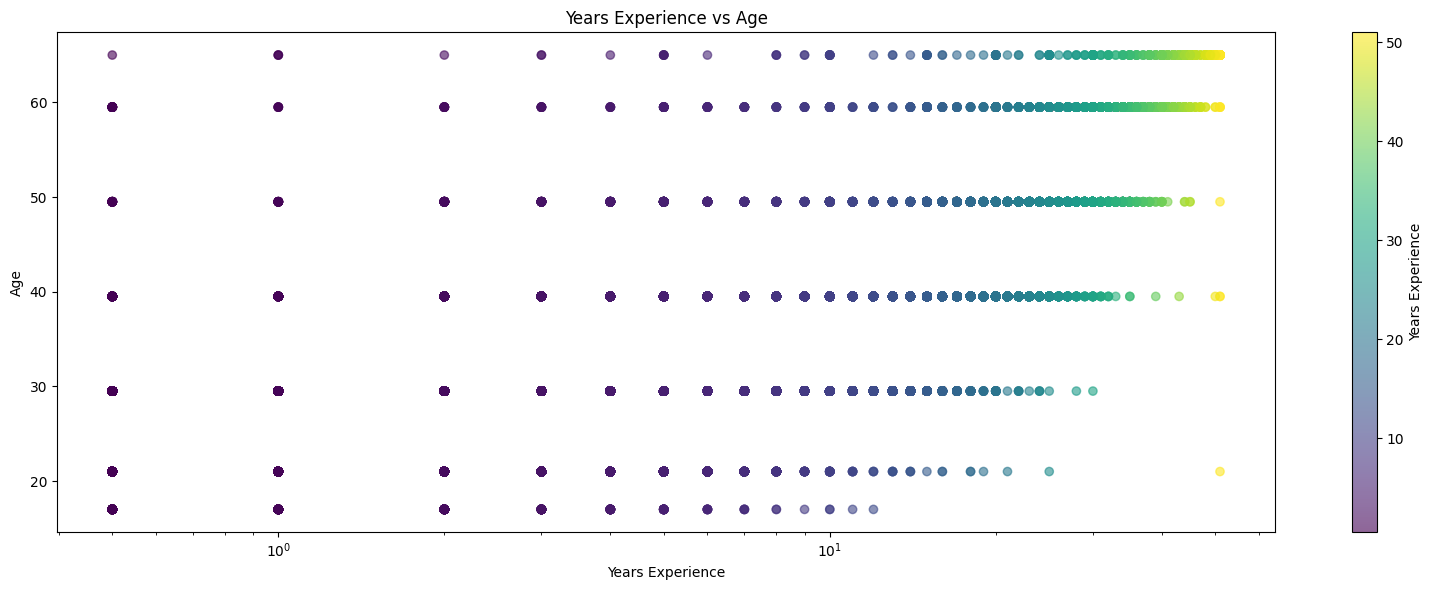

In [50]:
## Write your code here
age_map = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5 ,    
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 65}

df['Age_num'] = df['Age'].map(age_map)

Exp_df = df[['Age_num', 'YearsCodePro']].copy()

#clean yearscodepro
Exp_df['YearsCodePro'] = Exp_df['YearsCodePro'].replace({
    'Less than 1 year': 0.5,
    'More than 50 years': 51})

#ensure numerical values
Exp_df['YearsCodePro'] = pd.to_numeric(Exp_df['YearsCodePro'], errors='coerce')

Exp_df = Exp_df.dropna()

plt.figure(figsize=(16, 6))
scatter = plt.scatter(
    Exp_df['YearsCodePro'],
    Exp_df['Age_num'],
    c=Exp_df['YearsCodePro'],
    cmap='viridis',
    alpha=0.6)

plt.colorbar(scatter, label='Years Experience')
        
plt.title('Years Experience vs Age')
plt.xlabel('Years Experience')
plt.ylabel('Age')
plt.xscale('log')
plt.tight_layout()
plt.show()

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


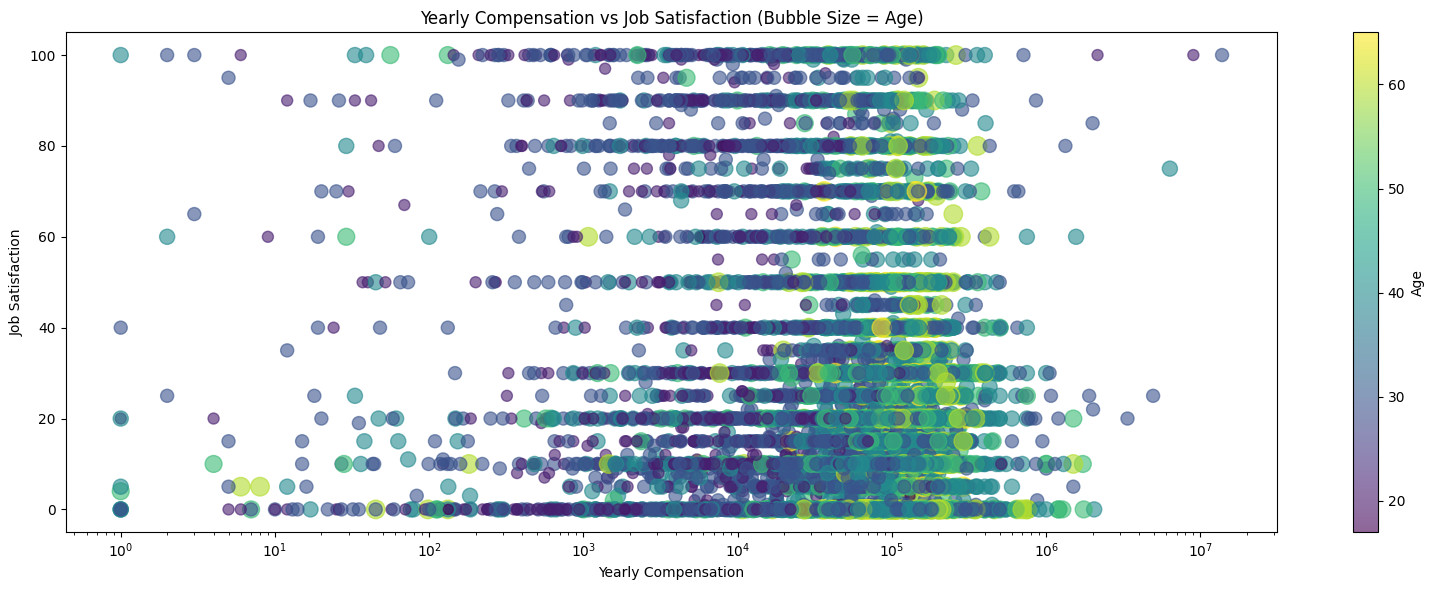

In [51]:
## Write your code here
#columns Age, ConvertedCompYearly, JobSatPoints_6
age_map = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5 ,    
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 65}

df['Age_num'] = df['Age'].map(age_map)
df['ConvertedCompYearly'].value_counts()

Comp_df= df[['ConvertedCompYearly', 'JobSatPoints_6', 'Age_num']].copy()
Comp_df = Comp_df.dropna()

#plotting - s=controls bubblesize
plt.figure(figsize=(16, 6))
scatter = plt.scatter(
    Comp_df['ConvertedCompYearly'],
    Comp_df['JobSatPoints_6'],
    s=Comp_df['Age_num']*3,
    c=Comp_df['Age_num'],
    cmap='viridis',
    alpha=0.6)

plt.colorbar(scatter, label='Age')
        
plt.title('Yearly Compensation vs Job Satisfaction (Bubble Size = Age)')
plt.xlabel('Yearly Compensation')
plt.ylabel('Job Satisfaction')
plt.xscale('log')
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


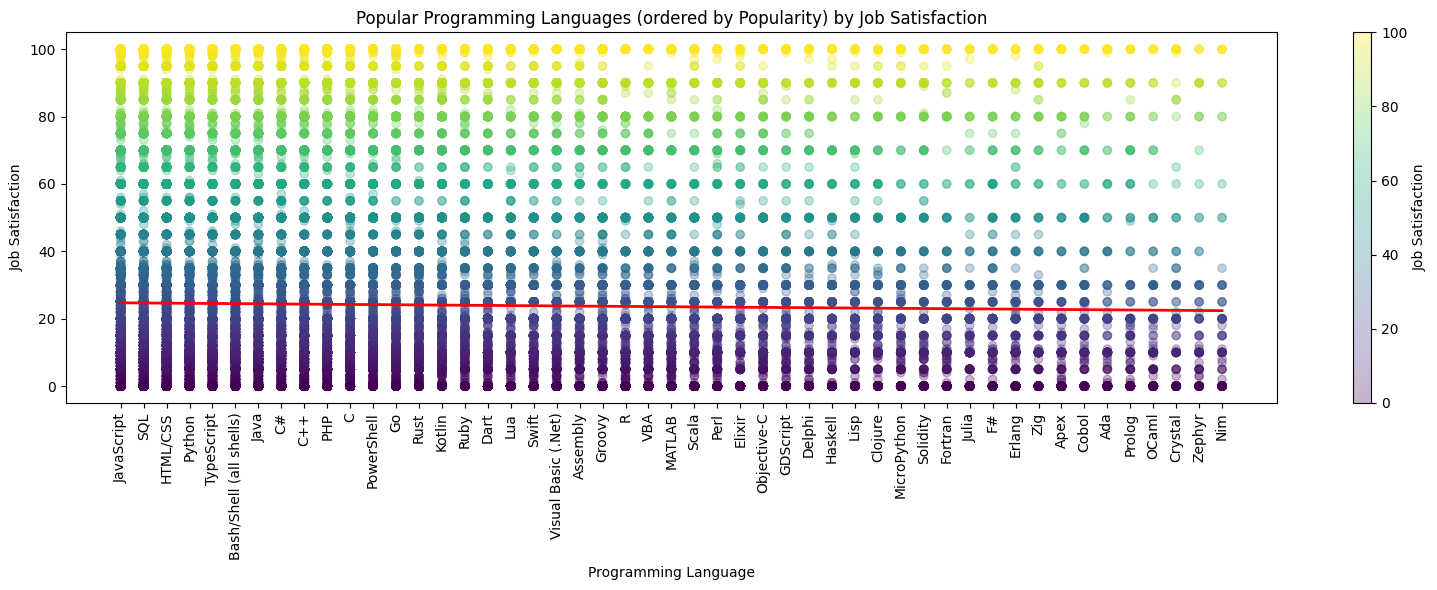

In [64]:
## Write your code here

#Cleaning - 
Lang_df = df[['LanguageHaveWorkedWith', 'JobSatPoints_6']].dropna().copy()

#Standardise
Lang_df['LanguageHaveWorkedWith'] = Lang_df['LanguageHaveWorkedWith'].astype(str).str.strip()

#splitting into seperate rows
lang_exploded = Lang_df.assign(LanguageHaveWorkedWith=Lang_df['LanguageHaveWorkedWith'].str.split(';')).explode('LanguageHaveWorkedWith')

#clean more after exploding
lang_exploded['LanguageHaveWorkedWith'] = lang_exploded['LanguageHaveWorkedWith'].str.strip()
lang_exploded = lang_exploded.dropna(subset=['LanguageHaveWorkedWith', 'JobSatPoints_6'])

#order languages by popularity
language_order = lang_exploded['LanguageHaveWorkedWith'].value_counts().index

lang_exploded['LanguageHaveWorkedWith'] = pd.Categorical(
    lang_exploded['LanguageHaveWorkedWith'],categories=language_order, ordered=True)
lang_exploded = lang_exploded.sort_values('LanguageHaveWorkedWith')

Lang_codes, Lang_names = pd.factorize(lang_exploded['LanguageHaveWorkedWith'])

plt.figure(figsize=(16, 6))

scatter = plt.scatter(
    Lang_codes,
    lang_exploded['JobSatPoints_6'],
    c=lang_exploded['JobSatPoints_6'],
    cmap='viridis',
    alpha=0.3)

plt.colorbar(scatter, label='Job Satisfaction')

#Regression line to show trend
m, b = np.polyfit(Lang_codes, lang_exploded['JobSatPoints_6'], 1)

sorted_idx = Lang_codes.argsort()
x_sorted = Lang_codes[sorted_idx]
y_pred = m * x_sorted + b

#m=slope, b=intercept
plt.plot(x_sorted, y_pred, color='red', linewidth=2)
        
plt.title('Popular Programming Languages (ordered by Popularity) by Job Satisfaction')
plt.xlabel('Programming Language')
plt.ylabel('Job Satisfaction')
plt.xticks(range(len(Lang_names)), Lang_names, rotation=90) 
plt.tight_layout()
plt.show()

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


In [65]:
df['Employment'].unique()

<StringArray>
[                                                                                                                                                          'Employed, full-time',
                                                                                                                                                            'Student, full-time',
                                                                                                                         'Student, full-time;Not employed, but looking for work',
                                                                                                                          'Independent contractor, freelancer, or self-employed',
                                                                                                                                        'Not employed, and not looking for work',
                                                                                                

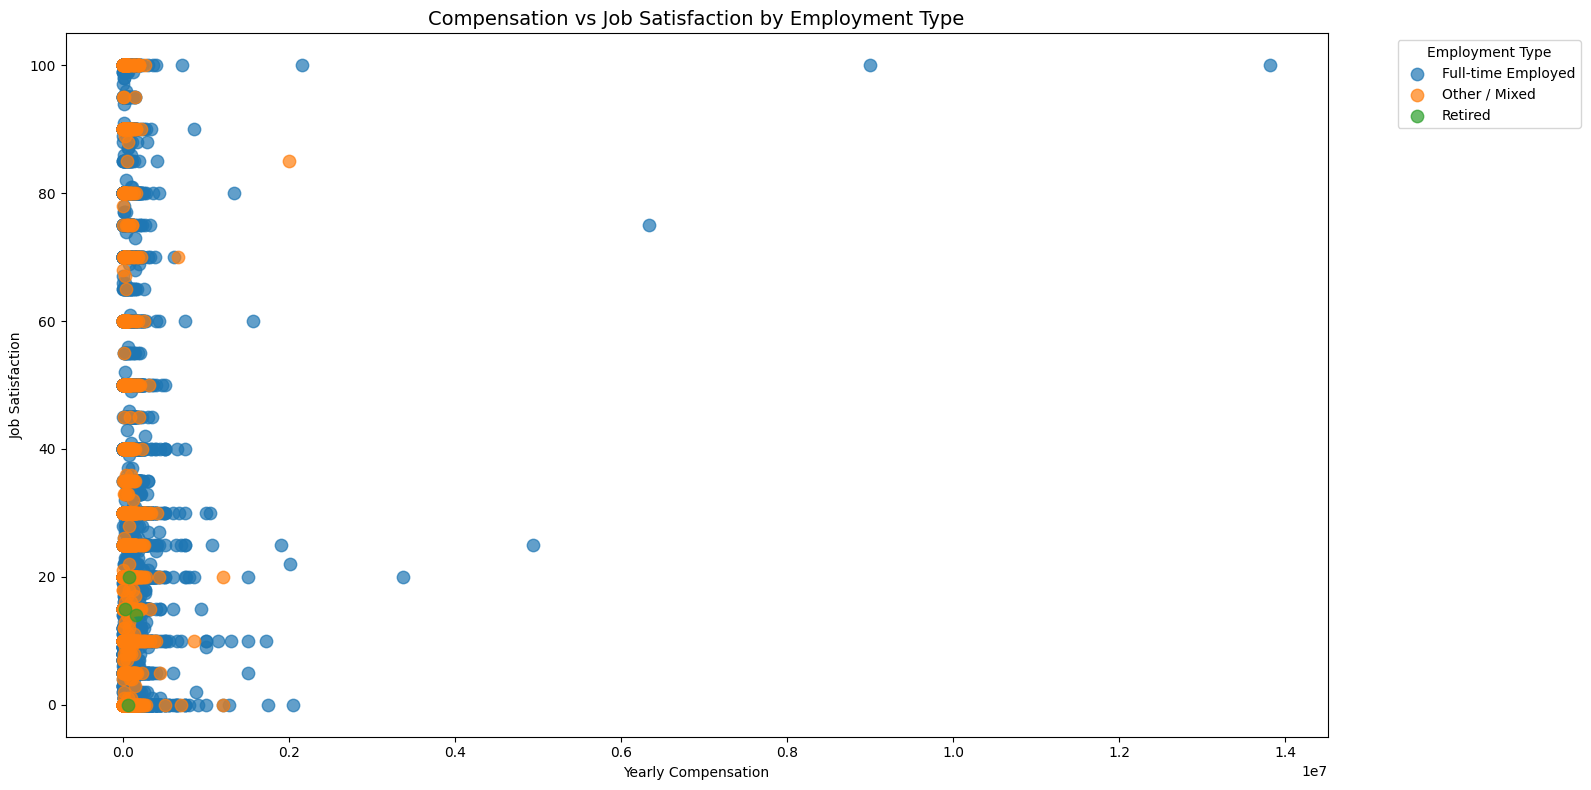

In [71]:
## Write your code here
#columns = ConvertedCompYearly, JobSatPoints_6, Employment

#Shorten Employment Labels and tidy - 
df['Employment_clean'] =( df['Employment']
.str.replace('Employed, full-time', 'Full-time Employed', regex=False)
.str.replace('Employed,part-time', 'Part-time Employed', regex=False)
.str.replace('Student,full-time', 'Full-time Student', regex=False)
.str.replace('Student,part-time', 'Part-time Student', regex=False)
.str.replace('Independentcontractor,freelancer,orself-employed', 'Self-employed / Contractor', regex=False)
.str.replace('Notemployed,butlookingforwork', 'Seeking Employment', regex=False)
.str.replace('Notemployed,andnotlookingforwork', 'Not-Seeking Employment', regex=False)
.str.replace('Retired', 'Retired', regex=False))

def simp_employment(emp):
    emp = str(emp)
    
    if 'Full-time Employed' in emp:
        return 'Full-time Employed'
    elif 'Part-time Employed' in emp:
        return 'Part-time Employed'
    elif 'Self-employed / Contractor' in emp:
        return 'Self-employed / contractor'
    elif 'Full-time Student' in emp or 'Part-time Student' in emp:
        return 'Student'
    elif 'Seeking Employment' in emp:
        return 'Seeking Employment'
    elif 'Not-Seeking Employment' in emp:
        return 'Not-Seeking Employment'
    elif 'Retired' in emp:
        return 'Retired'
    else:
        return 'Other / Mixed'

df['Employment_tidy'] = df['Employment_clean'].apply(simp_employment)

Comp_df= df[['ConvertedCompYearly', 'JobSatPoints_6', 'Employment_tidy']].copy()
Comp_df = Comp_df.dropna()

#plotting scatter
plt.figure(figsize=(16, 8))

#Loop through each employment type
for emp_type in Comp_df['Employment_tidy'].unique():
    subset = Comp_df[Comp_df['Employment_tidy'] == emp_type]

    scatter = plt.scatter(
        subset['ConvertedCompYearly'],
        subset['JobSatPoints_6'],
        label=emp_type,
        alpha=0.7,
        s=80)

        
plt.title('Compensation vs Job Satisfaction by Employment Type', fontsize=14)
plt.xlabel('Yearly Compensation')
plt.ylabel('Job Satisfaction')
plt.legend(title='Employment Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


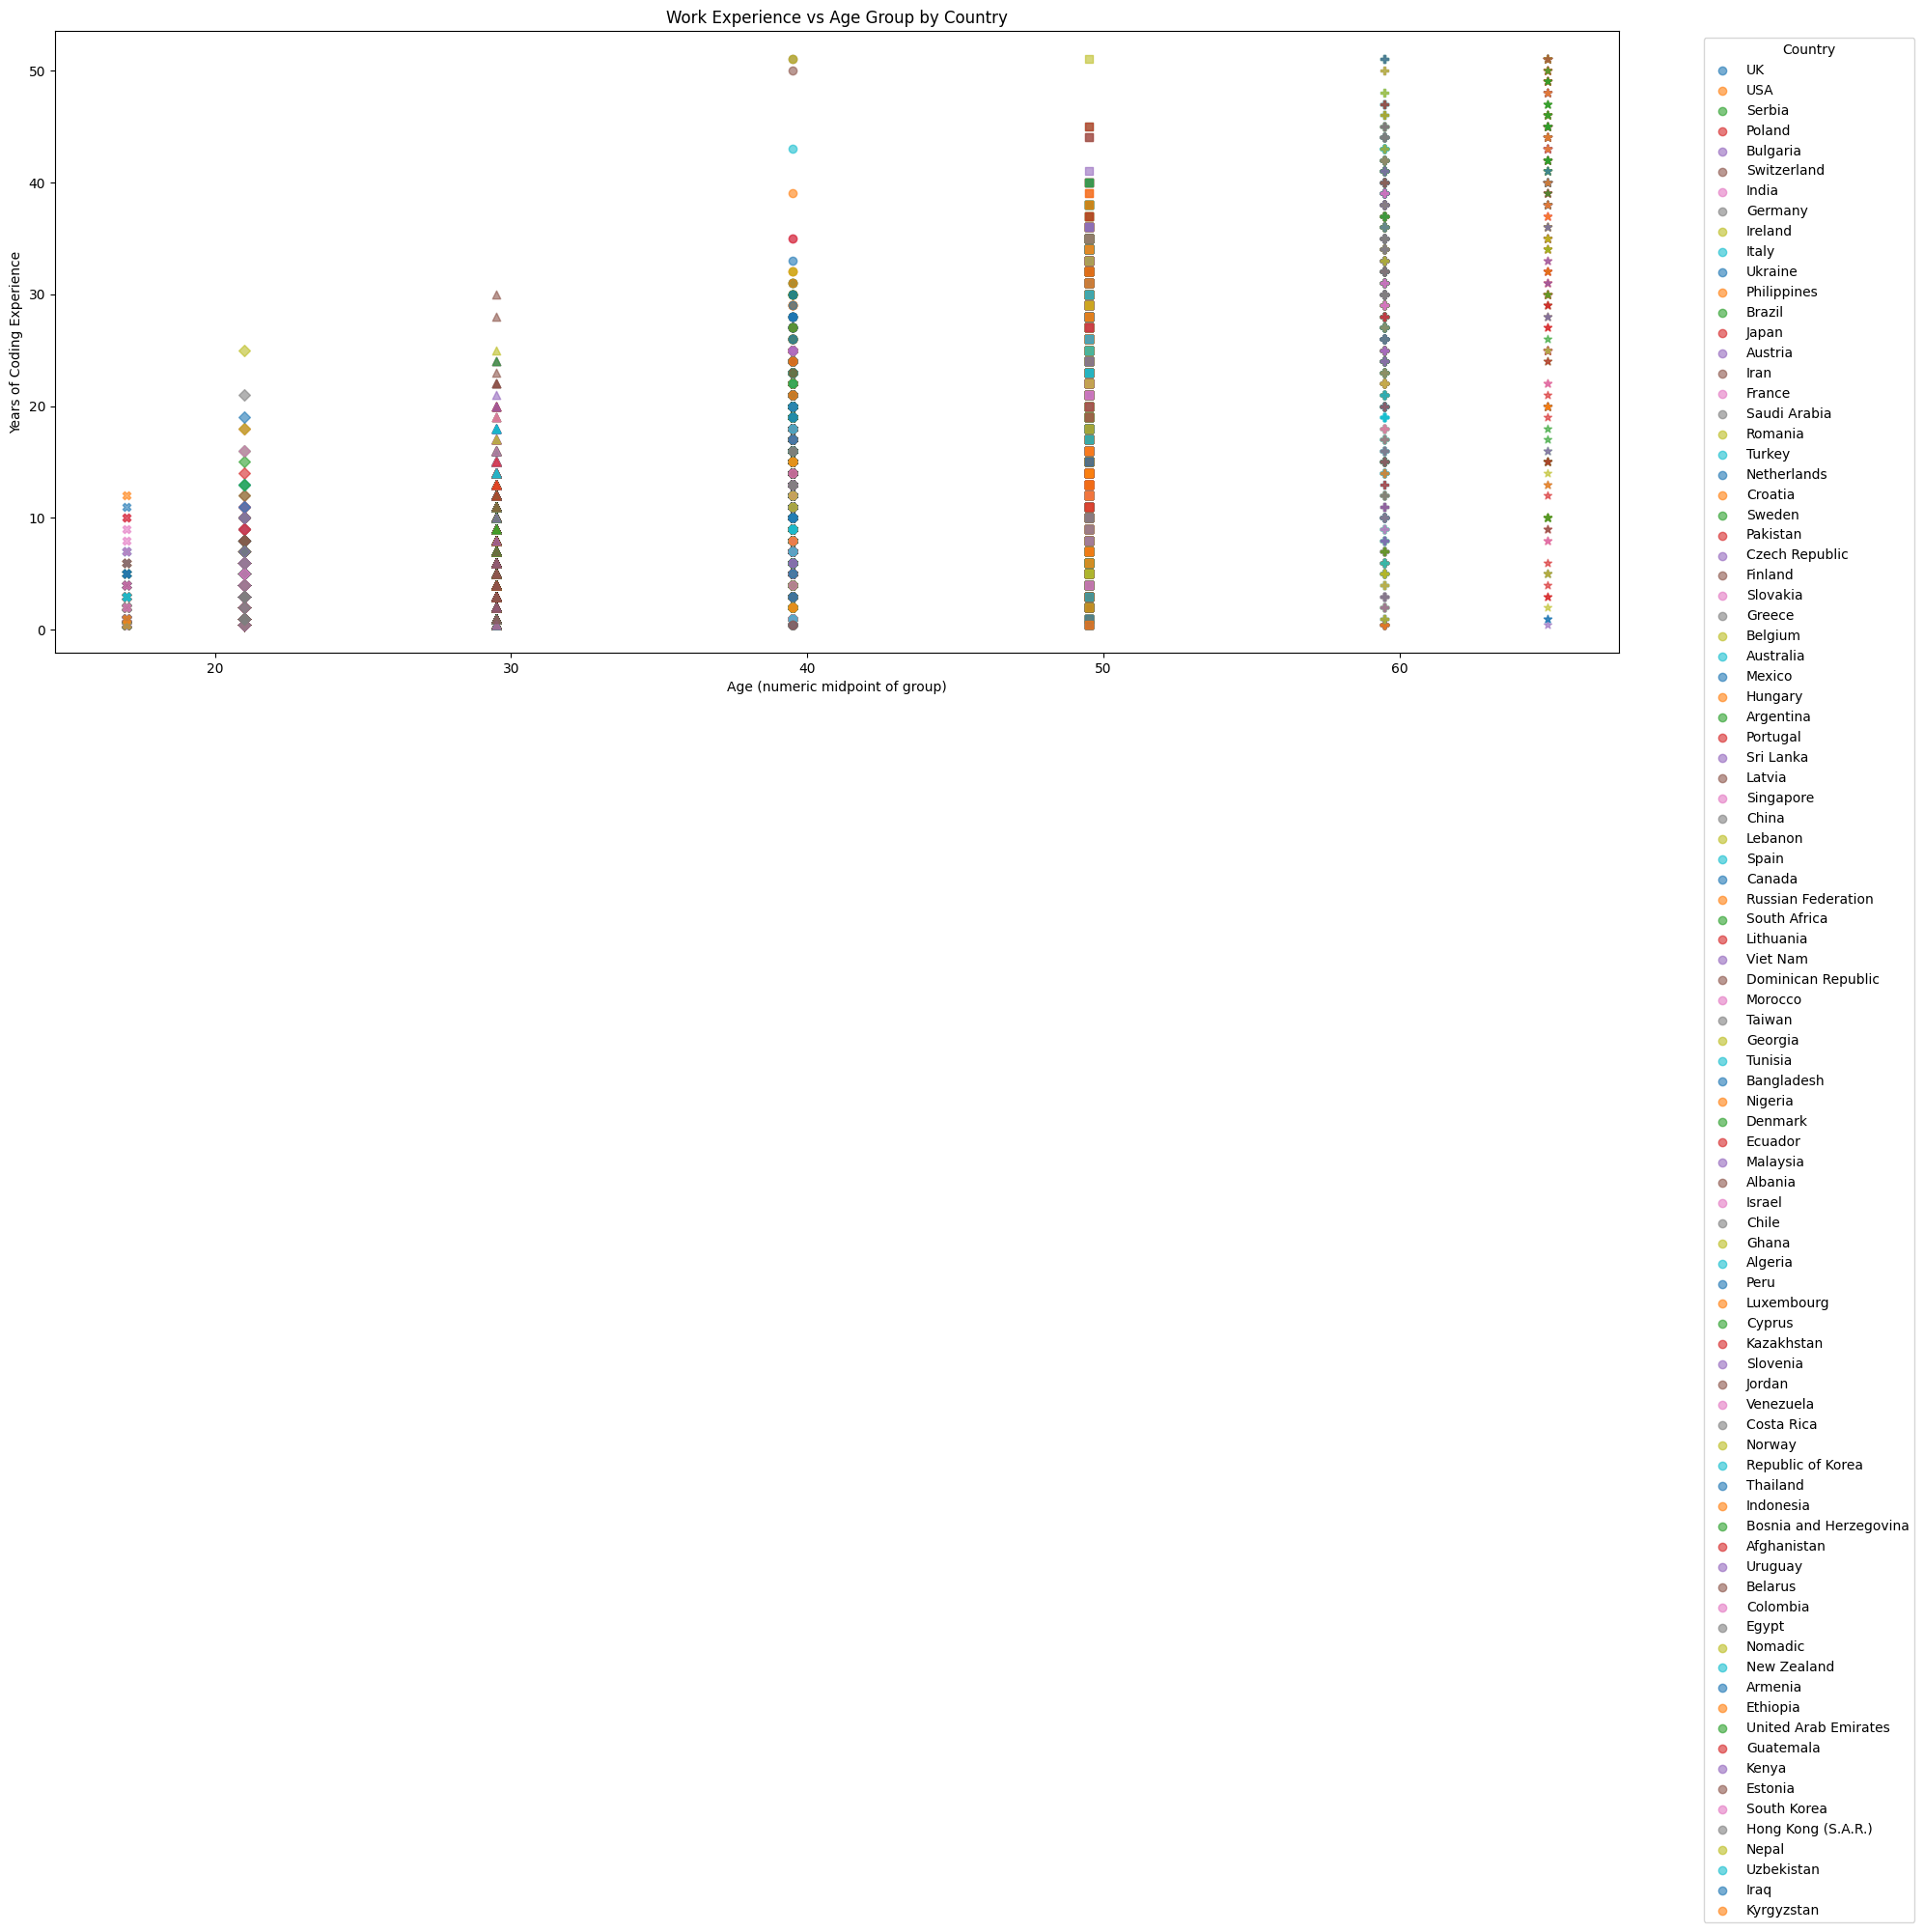

In [74]:
## Write your code here
#Columns = YearsCodePro, Age, Country

df['short_country'] = (df['Country'].str.replace('United States of America', 'USA', regex=False).str.replace('United Kingdom of Great Britain and Northern Ireland', 'UK', regex=False)
                       .str.replace(r',.*', '', regex=True).str.strip())

#count the number of responses per country
Country_count = df['short_country'].value_counts()

top_countries = Country_count[Country_count >=40].index #(may need to adjust this, trial and error)(originally started at 20)
df_filtered = df[df['short_country'].isin(top_countries)].copy()


age_map = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5 ,    
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 65}

df['Age_num'] = df['Age'].map(age_map)


Exp_df = df_filtered[['Age_num', 'Age', 'YearsCodePro', 'short_country']].copy()

#clean yearscodepro
Exp_df['YearsCodePro'] = Exp_df['YearsCodePro'].replace({
    'Less than 1 year': 0.5,
    'More than 50 years': 51})

#ensure numerical values
Exp_df['YearsCodePro'] = pd.to_numeric(Exp_df['YearsCodePro'], errors='coerce')

Exp_df = Exp_df.dropna()

plt.figure(figsize=(20, 15))

countries = Exp_df['short_country'].unique()
age_groups = Exp_df['Age'].unique()

markers = ['o', 's', '^', 'D', 'P', 'X', '*'] #one for each age catergory

for i, age_group in enumerate(age_groups):
    subset_age = Exp_df[Exp_df['Age'] == age_group]

    for country in countries:
        subset = subset_age[subset_age['short_country'] == country]
        
        plt.scatter(
            subset['Age_num'],
            subset['YearsCodePro'],
            label=f"{country} - {age_group}" if i == 0 else "",
            alpha=0.6,
            marker=markers[i % len(markers)])
    
        
plt.title('Work Experience vs Age Group by Country')
plt.xlabel('Age (numeric midpoint of group)')
plt.ylabel('Years of Coding Experience')
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:len(countries)], countries, title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
